In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import pickle

df=pd.read_csv('labeled_selected_routes_group_1.csv')

# przykładowo 6 równych kwantyli (możesz zmienić na 5,7)
df['delay_bin_q'] = pd.qcut(df['delay_min'].clip(lower=0), q=6, labels=False, duplicates='drop')

# df[df['delay_min']<-200]
df

,Unnamed: 0.1,Unnamed: 0,vehicle_id,trip_id,stop_sequence,day,planned_departure,timestamp,delay_sec,delay_min,route_name,time_label,delay_label,sin_time,cos_time,delay_bin_q
0,0,2,53,block_487_trip_6_service_1,14,2,2025-06-03 10:22:00,2025-06-03 10:25:59,239.0,3.983333,503,1020,3,0.422618,-0.906308,3
1,1,5,61,block_147_trip_7_service_1,3,2,2025-06-03 10:24:00,2025-06-03 10:25:59,119.0,1.983333,469,1020,2,0.422618,-0.906308,2
2,2,14,283,block_220_trip_8_service_1,15,2,2025-06-03 10:25:00,2025-06-03 10:25:57,57.0,0.950000,192,1025,1,0.402747,-0.915311,1
3,3,30,2,block_199_trip_8_service_1,3,2,2025-06-03 10:26:00,2025-06-03 10:26:29,29.0,0.483333,179,1025,1,0.402747,-0.915311,1
4,4,32,27,block_196_trip_7_service_1,16,2,2025-06-03 10:25:00,2025-06-03 10:26:29,89.0,1.483333,179,1025,2,0.402747,-0.915311,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140812,142204,1349865,573,block_964_trip_13_service_3,23,7,2025-06-29 23:34:00,2025-06-29 23:35:28,88.0,1.466667,469,2330,2,-0.130526,0.991445,2
140813,142205,1349869,573,block_964_trip_13_service_3,25,7,2025-06-29 23:40:00,2025-06-29 23:42:03,123.0,2.050000,469,2340,2,-0.087156,0.996195,2
140814,142206,1349870,573,block_964_trip_13_service_3,26,7,2025-06-29 23:43:00,2025-06-29 23:45:05,125.0,2.083333,469,2340,2,-0.087156,0.996195,2
140815,142207,1349873,573,block_964_trip_13_service_3,27,7,2025-06-29 23:45:00,2025-06-29 23:46:33,93.0,1.550000,469,2345,2,-0.065403,0.997859,2


In [51]:

objs = []
with open('../data/wyniki_predykcji/grupa_3_klasyfikacja_bez_cv_100_epoch','rb') as f:
    while True:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break

wyniki_zapis=objs[-1]


<Figure size 1200x500 with 0 Axes>

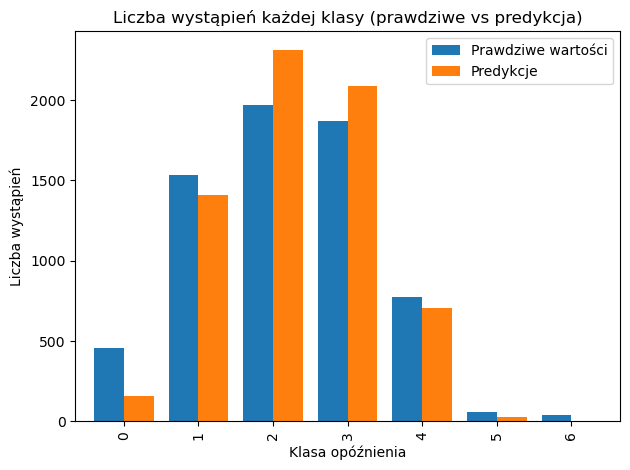

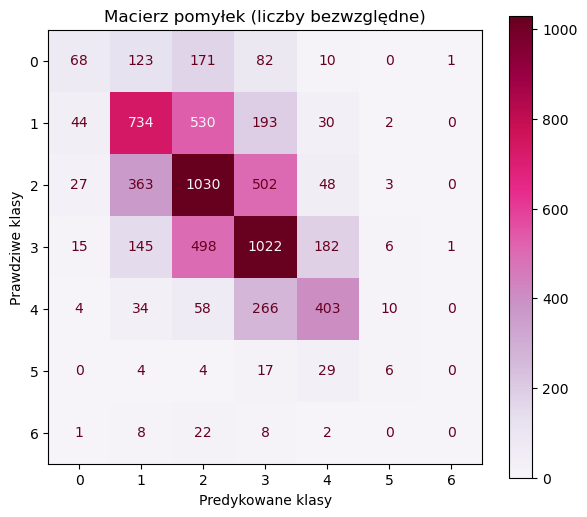

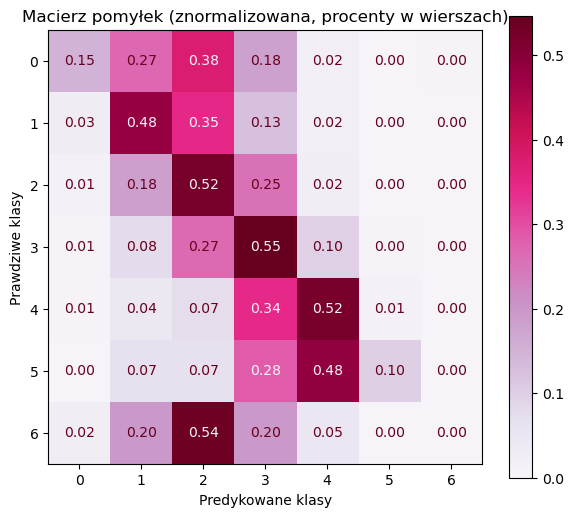

Precision dla każdej klasy:
Klasa 0: 0.428
Klasa 1: 0.520
Klasa 2: 0.445
Klasa 3: 0.489
Klasa 4: 0.572
Klasa 5: 0.222
Klasa 6: 0.000

Recall dla każdej klasy:
Klasa 0: 0.149
Klasa 1: 0.479
Klasa 2: 0.522
Klasa 3: 0.547
Klasa 4: 0.520
Klasa 5: 0.100
Klasa 6: 0.000

Średnia precision (macro): 0.382
Średnia recall (macro): 0.331


In [52]:
df_results = wyniki_zapis[2]
df_results = df_results.sort_values('orig_idx', ascending=True).set_index('orig_idx')
df_results=df_results.reset_index()

plt.figure(figsize=(12,5))
y_true_counts = df_results['y_true'].value_counts().sort_index()
y_pred_counts = df_results['y_pred'].value_counts().sort_index()

df_counts = pd.DataFrame({
    "Prawdziwe wartości": y_true_counts,
    "Predykcje": y_pred_counts
}).fillna(0).astype(int)

df_counts.plot(kind="bar", width=0.8)
plt.xlabel("Klasa opóźnienia")
plt.ylabel("Liczba wystąpień")
plt.title("Liczba wystąpień każdej klasy (prawdziwe vs predykcja)")
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(df_results['y_true'], df_results['y_pred'])
classes = sorted(df_results['y_true'].unique())

# Standard confusion matrix (absolute)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='PuRd')
plt.title(f"Macierz pomyłek (liczby bezwzględne)")
plt.xlabel("Predykowane klasy")
plt.ylabel("Prawdziwe klasy")
plt.show()

# Normalized confusion matrix (row norm)
cm_normalized = confusion_matrix(df_results['y_true'], df_results['y_pred'], normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=classes)
fig, ax = plt.subplots(figsize=(7, 6))
disp_norm.plot(ax=ax, cmap='PuRd', values_format=".2f")
plt.title(f"Macierz pomyłek (znormalizowana, procenty w wierszach)")
plt.xlabel("Predykowane klasy")
plt.ylabel("Prawdziwe klasy")
plt.show()


precision = precision_score(df_results['y_true'], df_results['y_pred'], average=None, zero_division=0)
recall = recall_score(df_results['y_true'], df_results['y_pred'], average=None, zero_division=0)

print("Precision dla każdej klasy:")
for c, p in zip(classes, precision):
    print(f"Klasa {c}: {p:.3f}")
print("\nRecall dla każdej klasy:")
for c, r in zip(classes, recall):
    print(f"Klasa {c}: {r:.3f}")

print(f"\nŚrednia precision (macro): {precision_score(df_results['y_true'], df_results['y_pred'], average='macro', zero_division=0):.3f}")
print(f"Średnia recall (macro): {recall_score(df_results['y_true'], df_results['y_pred'], average='macro', zero_division=0):.3f}")

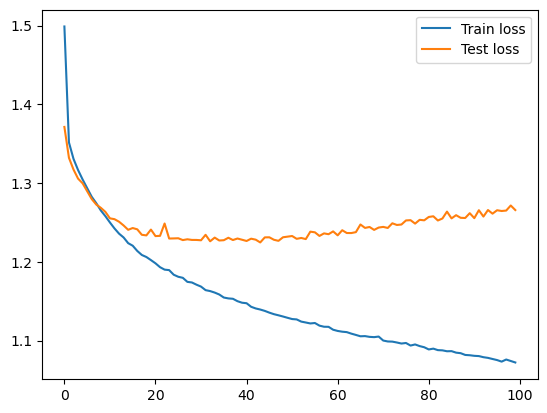

In [53]:
plt.figure
plt.plot(wyniki_zapis[0],label='Train loss')
plt.plot(wyniki_zapis[1],label='Test loss')
# plt.ylim([0,5])
plt.legend()
plt.show()

In [54]:
objs = []
with open('../data/wyniki_predykcji/grupa_1_klasyfikacja_5cv_30_epoch','rb') as f:
    while True:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break


wyniki=objs[-1]
for i in range(5):
    wyniki['fold_preds'][i] = wyniki['fold_preds'][i].sort_values('orig_idx', ascending=True).set_index('orig_idx')

print(wyniki['cv_losses'])

[1.2288331759942543, 1.2360836584288795, 1.232248188139082, 1.2287694344649445, 1.2418035435246992]


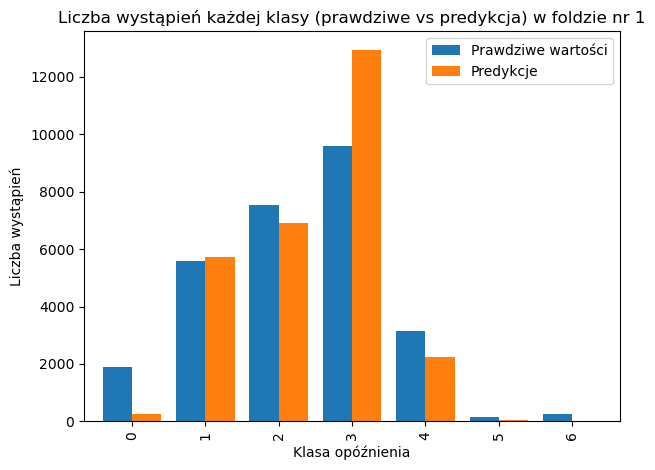

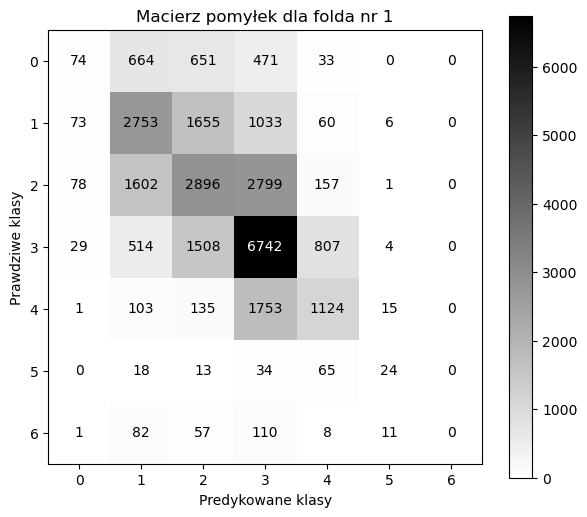

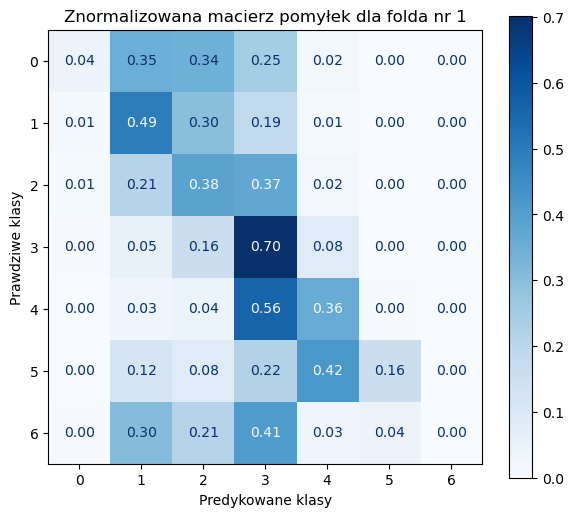

Fold 1:
  Klasa 0: precision = 0.289, recall = 0.039
  Klasa 1: precision = 0.480, recall = 0.493
  Klasa 2: precision = 0.419, recall = 0.384
  Klasa 3: precision = 0.521, recall = 0.702
  Klasa 4: precision = 0.499, recall = 0.359
  Klasa 5: precision = 0.393, recall = 0.156
  Klasa 6: precision = 0.000, recall = 0.000
  Macro Precision: 0.372, Macro Recall: 0.305



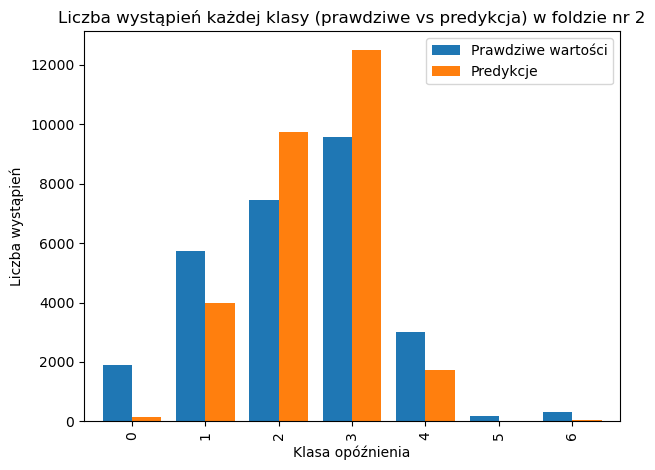

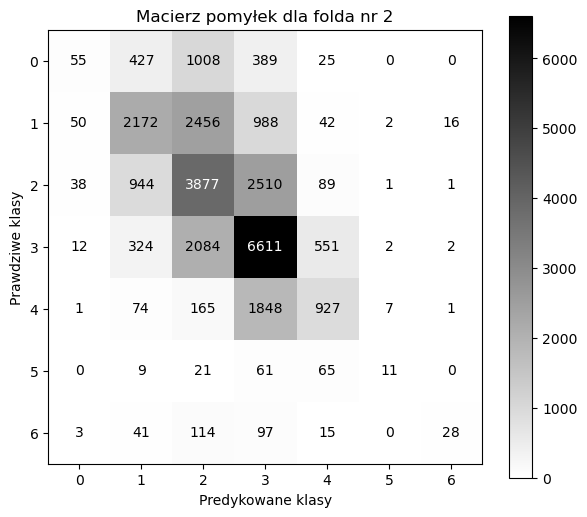

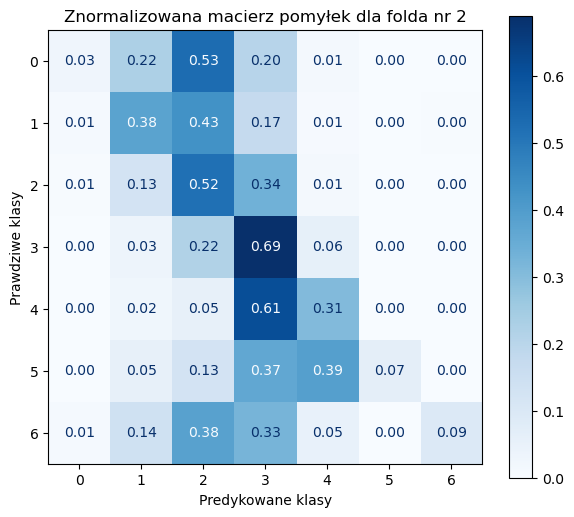

Fold 2:
  Klasa 0: precision = 0.346, recall = 0.029
  Klasa 1: precision = 0.544, recall = 0.379
  Klasa 2: precision = 0.399, recall = 0.520
  Klasa 3: precision = 0.529, recall = 0.690
  Klasa 4: precision = 0.541, recall = 0.307
  Klasa 5: precision = 0.478, recall = 0.066
  Klasa 6: precision = 0.583, recall = 0.094
  Macro Precision: 0.489, Macro Recall: 0.298



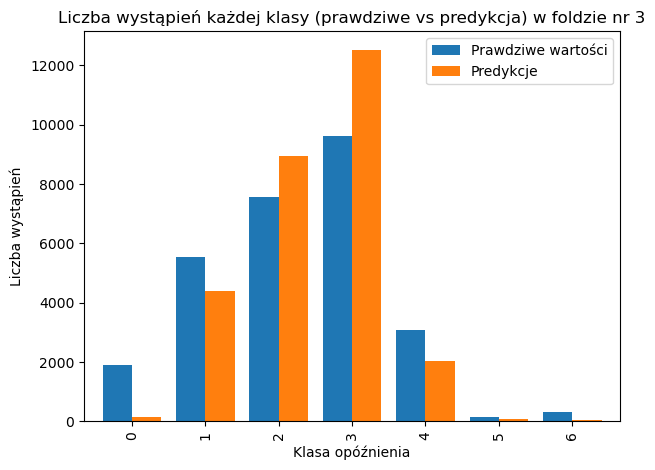

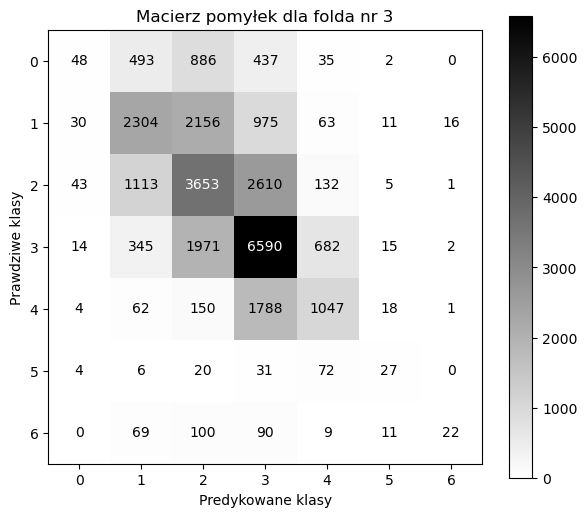

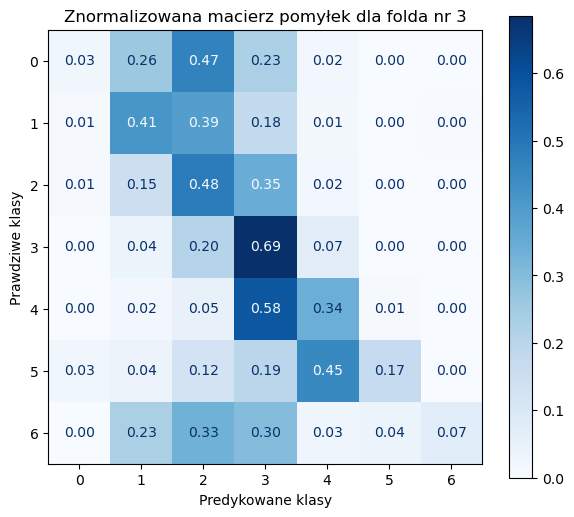

Fold 3:
  Klasa 0: precision = 0.336, recall = 0.025
  Klasa 1: precision = 0.525, recall = 0.415
  Klasa 2: precision = 0.409, recall = 0.483
  Klasa 3: precision = 0.526, recall = 0.685
  Klasa 4: precision = 0.513, recall = 0.341
  Klasa 5: precision = 0.303, recall = 0.169
  Klasa 6: precision = 0.524, recall = 0.073
  Macro Precision: 0.448, Macro Recall: 0.313



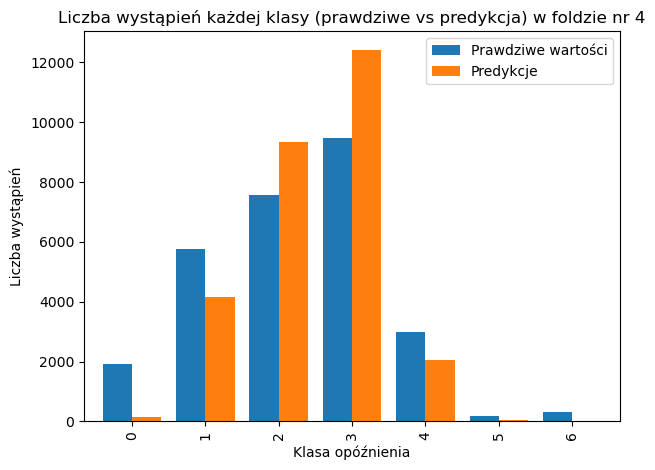

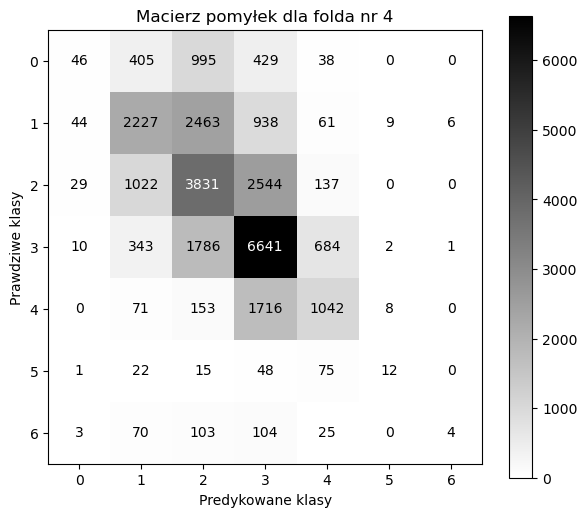

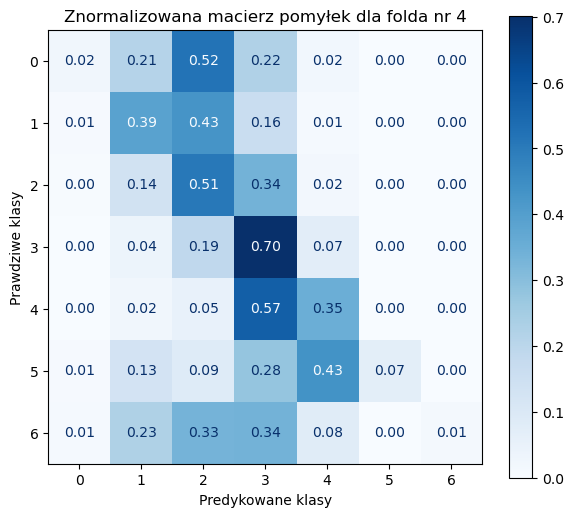

Fold 4:
  Klasa 0: precision = 0.346, recall = 0.024
  Klasa 1: precision = 0.535, recall = 0.387
  Klasa 2: precision = 0.410, recall = 0.507
  Klasa 3: precision = 0.535, recall = 0.701
  Klasa 4: precision = 0.505, recall = 0.348
  Klasa 5: precision = 0.387, recall = 0.069
  Klasa 6: precision = 0.364, recall = 0.013
  Macro Precision: 0.440, Macro Recall: 0.293



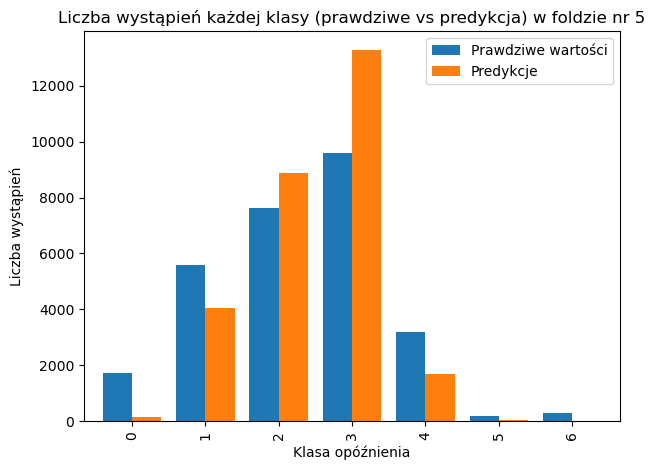

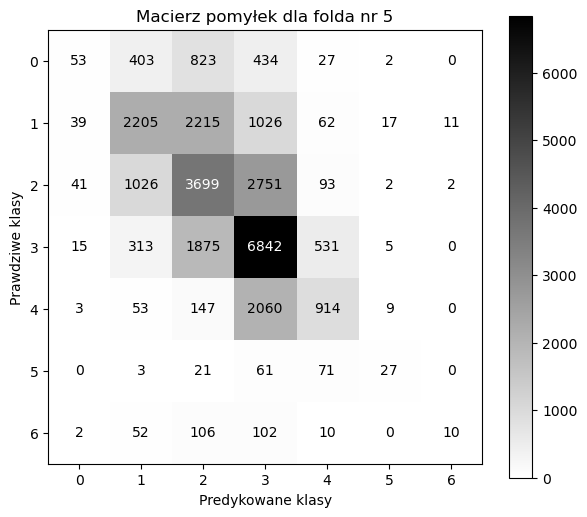

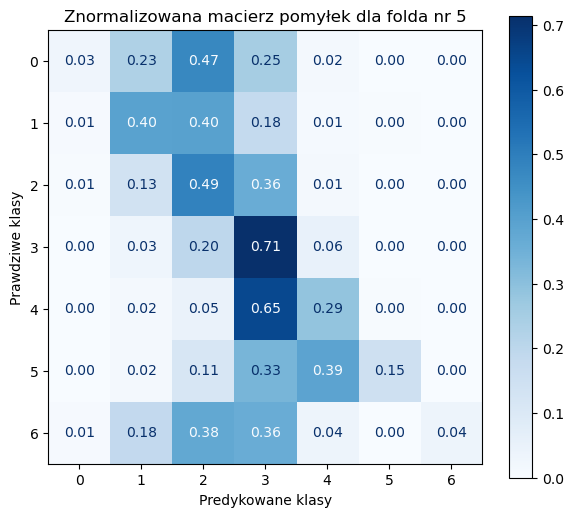

Fold 5:
  Klasa 0: precision = 0.346, recall = 0.030
  Klasa 1: precision = 0.544, recall = 0.396
  Klasa 2: precision = 0.416, recall = 0.486
  Klasa 3: precision = 0.515, recall = 0.714
  Klasa 4: precision = 0.535, recall = 0.287
  Klasa 5: precision = 0.435, recall = 0.148
  Klasa 6: precision = 0.435, recall = 0.035
  Macro Precision: 0.461, Macro Recall: 0.299



In [55]:

for i in range(5):
    predykcje = wyniki['fold_preds'][i]
    y_true_counts = predykcje['y_true'].value_counts().sort_index()
    y_pred_counts = predykcje['y_pred'].value_counts().sort_index()
    df_counts = pd.DataFrame({
        "Prawdziwe wartości": y_true_counts,
        "Predykcje": y_pred_counts
    }).fillna(0).astype(int)

    df_counts.plot(kind="bar", width=0.8)
    plt.xlabel("Klasa opóźnienia")
    plt.ylabel("Liczba wystąpień")
    plt.title(f"Liczba wystąpień każdej klasy (prawdziwe vs predykcja) w foldzie nr {i+1}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(predykcje['y_true'], predykcje['y_pred'])
    classes = sorted(predykcje['y_true'].unique())

    # Standard confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap='binary')
    plt.title(f"Macierz pomyłek dla folda nr {i+1}")
    plt.xlabel("Predykowane klasy")
    plt.ylabel("Prawdziwe klasy")
    plt.show()

    # Normalized confusion matrix
    cm_norm = confusion_matrix(predykcje['y_true'], predykcje['y_pred'], normalize='true')
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp_norm.plot(ax=ax, cmap='Blues', values_format='.2f')
    plt.title(f"Znormalizowana macierz pomyłek dla folda nr {i+1}")
    plt.xlabel("Predykowane klasy")
    plt.ylabel("Prawdziwe klasy")
    plt.show()

    # Oblicz precision i recall dla każdej klasy w foldzie
    precision = precision_score(predykcje['y_true'], predykcje['y_pred'], average=None, zero_division=0, labels=classes)
    recall = recall_score(predykcje['y_true'], predykcje['y_pred'], average=None, zero_division=0, labels=classes)
    print(f"Fold {i+1}:")
    for c, p, r in zip(classes, precision, recall):
        print(f"  Klasa {c}: precision = {p:.3f}, recall = {r:.3f}")
    # Średnie wartości (macro)
    macro_precision = precision_score(predykcje['y_true'], predykcje['y_pred'], average='macro', zero_division=0)
    macro_recall = recall_score(predykcje['y_true'], predykcje['y_pred'], average='macro', zero_division=0)
    print(f"  Macro Precision: {macro_precision:.3f}, Macro Recall: {macro_recall:.3f}\n")


